# Proyek Menyelesaikan Permasalahan Human Resources

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

### Menyiapkan data yang akan digunakan

## Data Understanding

In [ ]:
# Load data
df = pd.read_csv("employee_data.csv")

In [ ]:
# Tampilkan info awal
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [ ]:
# Cek nilai unik dari setiap kolom (untuk memahami tipe datanya)
for col in df.columns:
    print(f"\n{col} -> {df[col].unique()[:5]}")


EmployeeId -> [1 2 3 4 5]

Age -> [38 37 51 42 40]

Attrition -> [nan  1.  0.]

BusinessTravel -> ['Travel_Frequently' 'Travel_Rarely' 'Non-Travel']

DailyRate -> [1444 1141 1323  555 1194]

Department -> ['Human Resources' 'Research & Development' 'Sales']

DistanceFromHome -> [ 1 11  4 26  2]

Education -> [4 2 3 1 5]

EducationField -> ['Other' 'Medical' 'Life Sciences' 'Marketing' 'Technical Degree']

EmployeeCount -> [1]

EnvironmentSatisfaction -> [4 1 3 2]

Gender -> ['Male' 'Female']

HourlyRate -> [88 61 34 77 98]

JobInvolvement -> [3 1 2 4]

JobLevel -> [1 2 4 5 3]

JobRole -> ['Human Resources' 'Healthcare Representative' 'Research Scientist'
 'Sales Executive' 'Manager']

JobSatisfaction -> [2 3 4 1]

MaritalStatus -> ['Married' 'Single' 'Divorced']

MonthlyIncome -> [ 2991  4777  2461 13525  2001]

MonthlyRate -> [ 5224 14382 10332 14864 12549]

NumCompaniesWorked -> [0 5 9 2 1]

Over18 -> ['Y']

OverTime -> ['Yes' 'No']

PercentSalaryHike -> [11 15 12 14 22]

Performanc

In [ ]:
# Info data
print("\nInfo Data:")
df.info()


Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 

In [ ]:
# Cek missing values
print("\nJumlah missing value per kolom:")
df.isnull().sum()


Jumlah missing value per kolom:


,0
EmployeeId,0
Age,0
Attrition,412
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


In [ ]:
# Distribusi target
print("\nDistribusi 'Attrition':\n", df['Attrition'].value_counts(dropna=False))


Distribusi 'Attrition':
 Attrition
0.0    879
NaN    412
1.0    179
Name: count, dtype: int64


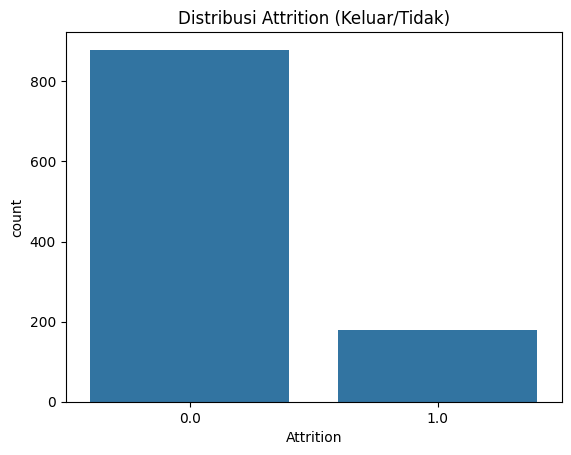

In [ ]:
# Melihat distribusi target Attrition
sns.countplot(x=df['Attrition'])
plt.title("Distribusi Attrition (Keluar/Tidak)")
plt.show()

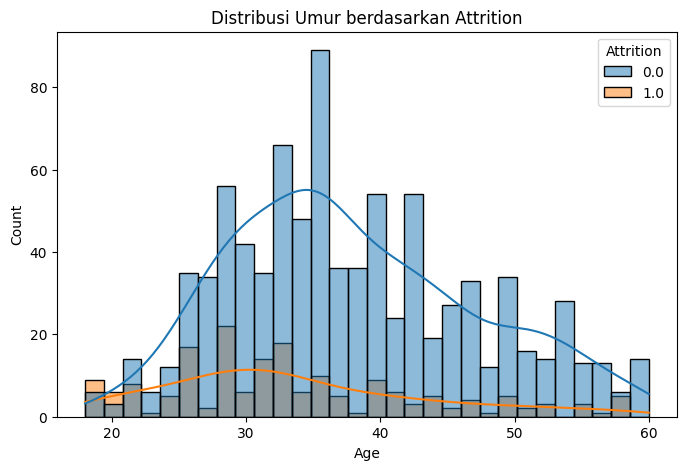

In [ ]:
# Melihat distribusi umur karyawan yang keluar dan bertahan
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", hue="Attrition", kde=True, bins=30)
plt.title("Distribusi Umur berdasarkan Attrition")
plt.show()

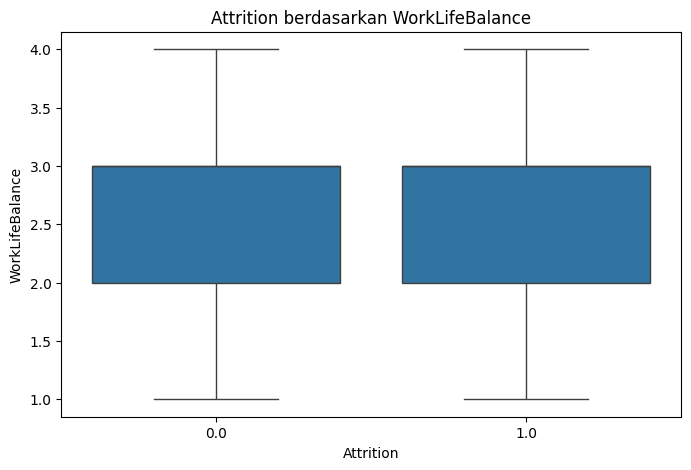

In [ ]:
# Analisis pengaruh WorkLifeBalance terhadap Attrition
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="WorkLifeBalance", data=df)
plt.title("Attrition berdasarkan WorkLifeBalance")
plt.show()

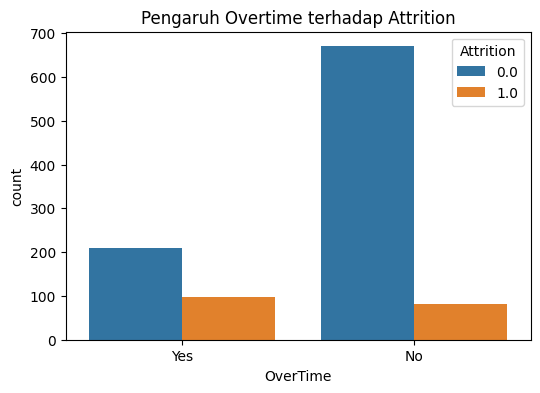

In [ ]:
# Analisis pengaruh Overtime terhadap Attrition
plt.figure(figsize=(6,4))
sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("Pengaruh Overtime terhadap Attrition")
plt.show()

## Data Preparation / Preprocessing

In [ ]:
# Hapus baris yang tidak memiliki nilai
df = df.dropna(subset=['Attrition'])

In [ ]:
# Konversi kolom Attrition menjadi tipe data integer
df['Attrition'] = df['Attrition'].astype(int)

<ipython-input-13-3d85bebdce7e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Attrition'] = df['Attrition'].astype(int)


In [ ]:
# Hapus kolom yang tidak perlu
df = df.drop(columns=['EmployeeId', 'EmployeeCount', 'Over18', 'StandardHours'])

In [ ]:
# Pisahkan fitur dan target
X = df.drop(columns=['Attrition'])
y = df['Attrition']

In [ ]:
# One-hot encoding untuk fitur kategorik
X = pd.get_dummies(X)

In [ ]:
# Scaling fitur numerik
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Cek ulang apakah masih ada NaN
print("NaN di X:", np.isnan(X_scaled).sum())
print("NaN di y:", y.isna().sum())

NaN di X: 0
NaN di y: 0


In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

print("Jumlah training:", len(X_train), "Jumlah testing:", len(X_test))

Jumlah training: 846 Jumlah testing: 212


## Modeling

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:41:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

## Evaluation

In [ ]:
# Fungsi evaluasi
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{model_name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Logistic Regression
Accuracy: 0.8679245283018868
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       176
           1       0.64      0.50      0.56        36

    accuracy                           0.87       212
   macro avg       0.77      0.72      0.74       212
weighted avg       0.86      0.87      0.86       212



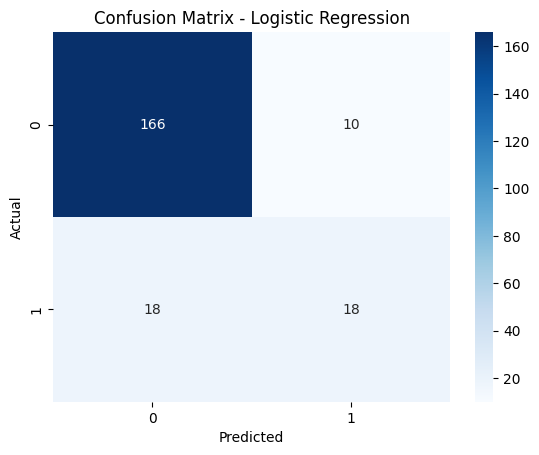

In [ ]:
# Evaluasi model Logistic Regression
evaluate_model(y_test, lr.predict(X_test), "Logistic Regression")


Random Forest
Accuracy: 0.8632075471698113
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.99      0.92       176
           1       0.89      0.22      0.36        36

    accuracy                           0.86       212
   macro avg       0.88      0.61      0.64       212
weighted avg       0.87      0.86      0.83       212



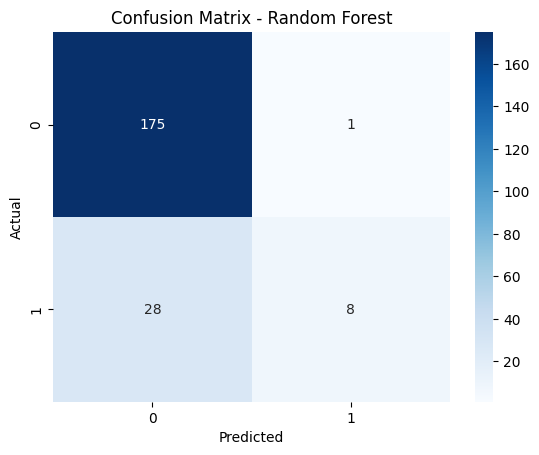

In [ ]:
# Evaluasi model Random Forest
evaluate_model(y_test, rf.predict(X_test), "Random Forest")


XGBoost
Accuracy: 0.8349056603773585
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.94      0.90       176
           1       0.52      0.31      0.39        36

    accuracy                           0.83       212
   macro avg       0.70      0.62      0.65       212
weighted avg       0.81      0.83      0.82       212



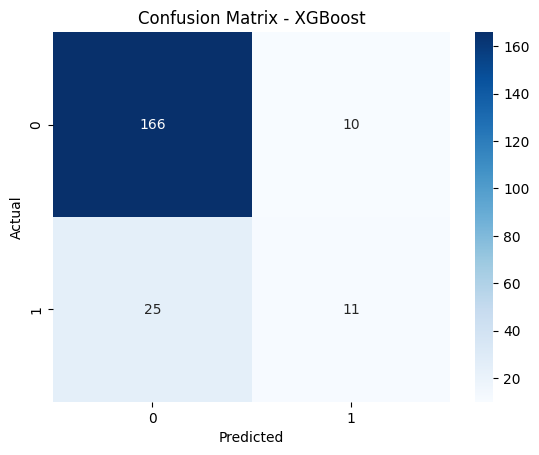

In [ ]:
# Evaluasi model XGBoost
evaluate_model(y_test, xgb.predict(X_test), "XGBoost")

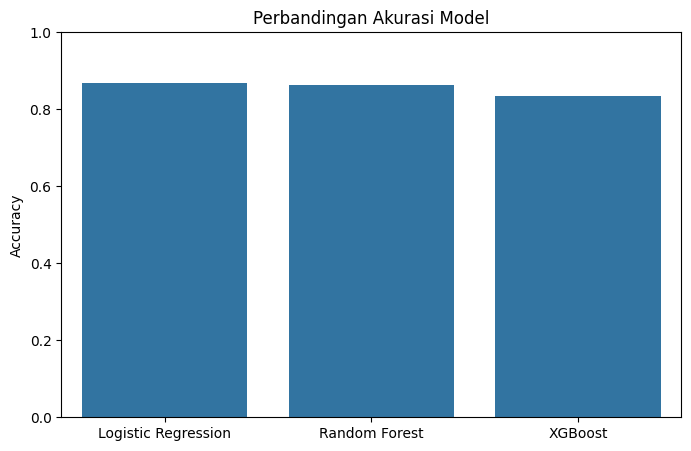

In [ ]:
# Perbandingan akurasi semua model
model_scores = {
    'Logistic Regression': accuracy_score(y_test, lr.predict(X_test)),
    'Random Forest': accuracy_score(y_test, rf.predict(X_test)),
    'XGBoost': accuracy_score(y_test, xgb.predict(X_test))
}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(model_scores.keys()), y=list(model_scores.values()))
plt.ylim(0, 1)
plt.title("Perbandingan Akurasi Model")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
!pip freeze > requirements.txt